In [1]:

import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 

epoch_path = "E:/workspace/study2_escape_task_eeg/eeg_process/" # 分析哪个roi就输入哪个文件夹的数据

behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据


subjects = [4, 5, 6, 8, 9, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45,46,47, 49,50,51,52] 


In [2]:
channel_location_dict = {"Fp1":	[-26.25, 83, -18.25],
"Fp2": [26.25, 83, -18.25],
"F3": [-48.75, 57.5, 36.5],
"F4": [48.75, 57.5, 36.5],
"C3": [-63.75, -13, 65.75],
"C4": [63.75, -13, 65.75],
"P3": [-48, -86.5, 53],
"P4": [48, -86.5, 53],
"O1": [-27, -118, 4.25],
"O2": [27, -118, 4.25],
"F7": [-69, 44, -18.25],
"F8": [69, 44, -18.25],
"T7": [-84, -18.25, -13],
"T8": [84, -18.25, -13],
"P7": [-69, -80.5, -4.75],
"P8": [69, -80.5, -4.75],
"Fz": [0, 63.5, 59],
"Cz": [0, -10, 99.5],
"Pz": [0, -88, 77],
"FC1": [-32.25, 28.25, 77.75],
"FC2": [32.25, 28.25, 77.75],
"CP1": [-35.25, -52, 90.5],
"CP2": [35.25, -52, 90.5],
"FC5": [-75.75, 20, 21.5],
"FC6": [75.75, 20, 21.5],
"CP5": [-78, -51.25, 31.25],
"CP6": [78, -51.25, 31.25],
"FT9": [-72.75, 8.75, -55.75],
"FT10": [72.75, 8.75, -55.75],
"TP9": [-71.25, -49, -49.75],
"TP10": [71.25, -49, -49.75],
"F1": [-25.5, 62, 53.75],
"F2": [25.5, 62, 53.75],
"C1": [-35.25, -11.5, 89.75],
"C2": [35.25, -11.5, 89.75],
"P1": [-27, -88, 70.25],
"P2": [27, -88, 70.25],
"AF3": [-32.25, 80.75, 11.75],
"AF4": [32.25, 80.75, 11.75],
"FC3": [-59.25, 25.25, 54.5],
"FC4": [59.25, 25.25, 54.5],
"CP3": [-63, -52, 66.5],
"CP4": [63, -52, 66.5],
"PO3": [-31.5, -109.75, 32.75],
"PO4": [31.5, -109.75, 32.75],
"F5": [-63, 51.5, 11.75],
"F6": [63, 51.5, 11.75],
"C5": [-81.75, -14.5, 29],
"C6": [81.75, -14.5, 29],
"P5": [-63.75, -83.5, 26.75],
"P6": [63.75, -83.5, 26.75],
"AF7": [-50.25, 68, -19],
"AF8": [50.25, 68, -19],
"FT7": [-79.5, 15.5, -16],
"FT8": [79.5, 15.5, -16],
"TP7": [-80.25, -49.75, -8.5],
"TP8": [80.25, -49.75, -8.5],
"PO7": [-50.25, -103, 0.5],
"PO8": [50.25, -103, 0.5],
"Fpz": [0, 83, -18.25],
"CPz": [0, -53.5, 98],
"POz": [0, -109, 44],
"Oz": [0, -122.5, 8]}
# ['Fp1', 'Fp2', 'Fz', 'Cz', 'Pz', 'Fpz', 'CPz', 'POz', 'Oz'].
mymontage = mne.channels.make_dig_montage(ch_pos=channel_location_dict)#, nasion=[0, -10, 99.5], lpa=[-71.25, -49, -49.75], 
#                                        rpa=[71.25, -49, -49.75])

In [ ]:
#个体水平
from mne.time_frequency import tfr_morlet

freqs=np.arange(4, 31, 1) # 4 5 6 7     8 9 10 11 12 13
n_cycles = np.linspace(2, 5, num=27)
# freqs = freqs[0:4]  # theta
# n_cycles = n_cycles[0:4]
# freqs = freqs[4:10]  # Alpha
# n_cycles = n_cycles[4:10]
freqs = freqs[10:]  # Beta
n_cycles = n_cycles[10:]

# n_cycles =4
time_span = 100
ch_names = []
decision_time_range = [-1.0, 5] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s

# 生成时间序列
time_range = np.arange(baseline_range[0]-baseline_range[1] + decision_time_range[0], decision_time_range[1]-0.001, 0.004)

all_sub_imminent_data = []
all_sub_moderate_data = []
imminent_trial_num, moderate_trial_num = 0, 0
for i in range(len(subjects)):

    # 导入数据 删除眼电 设置电极位置
    EEG_epochs = mne.read_epochs_eeglab(epoch_path + 'sub' + str(subjects[i]) + '.set')

    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 16)
    # 降采样
    EEG_epochs.resample(250)

    # 导入行为数据
    hebavior_trial = pd.read_excel(behavior_path + str(subjects[i]) + '/subject_v4.xlsx')

    print(len(hebavior_trial))

    safe_imminent_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & ~(hebavior_trial['firsttime_stage_3'].str.len() > 0)))
    safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) ) & ~(hebavior_trial['firsttime_stage_3'].str.len()> 0)))

    imminent_trial_num +=  len(safe_imminent_event_num)
    moderate_trial_num += len(safe_moderate_event_num)
    # 统一计算tfr
    tfr_epochs_safe_imminent = tfr_morlet(EEG_epochs[safe_imminent_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)
    tfr_epochs_safe_moderate = tfr_morlet(EEG_epochs[safe_moderate_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)

    # 截取baseline的信号作为基准  baseline_range
    tfr_epochs_safe_imminent_baseline_data = tfr_epochs_safe_imminent.copy().crop(baseline_range[0], baseline_range[1]-0.004).data
    tfr_epochs_safe_moderate_baseline_data = tfr_epochs_safe_moderate.copy().crop(baseline_range[0], baseline_range[1]-0.004).data

    # 高威胁攻击
    discarded_trial_1 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_imminent_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_imminent_event_num[iter_trial]]))
        if iter_trialtime[1] < 16 - 0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_imminent_data = tfr_epochs_safe_imminent.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.004).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_imminent_data = iter_safe_imminent_data
                empty_or_not = 1
            else: 
                iter_subject_safe_imminent_data = np.vstack((iter_subject_safe_imminent_data, iter_safe_imminent_data))
        else:
            discarded_trial_1.append(iter_trial)

    # 低威胁攻击
    discarded_trial_2 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_moderate_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_moderate_event_num[iter_trial]]))
        if iter_trialtime[1] < 16-0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_moderate_data = tfr_epochs_safe_moderate.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.004).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_moderate_data = iter_safe_moderate_data
                empty_or_not = 1
            else: 
                iter_subject_safe_moderate_data = np.vstack((iter_subject_safe_moderate_data, iter_safe_moderate_data))
        else:
            discarded_trial_2.append(iter_trial)

    # 合并基线段和选择段的数据, slow情况下太长的数据删除
    # iter_subject_safe_imminent_data = np.concatenate((tfr_epochs_safe_imminent_baseline_data, iter_subject_safe_imminent_data), axis=3)
    iter_subject_safe_imminent_data = np.concatenate((np.delete(tfr_epochs_safe_imminent_baseline_data, discarded_trial_1, axis=0), iter_subject_safe_imminent_data), axis=3)

    iter_subject_safe_moderate_data = np.concatenate((np.delete(tfr_epochs_safe_moderate_baseline_data, discarded_trial_2, axis=0), iter_subject_safe_moderate_data), axis=3)

    # 生成mne的tfr文件准备进行基线校正
    info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

    # 将所有trial进行平均,矫正前平均
    all_safe_imminent_mean_data = np.mean(iter_subject_safe_imminent_data, axis=0)
    all_safe_moderate_mean_data = np.mean(iter_subject_safe_moderate_data, axis=0)

    # 矫正前平均
    all_safe_imminent_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_safe_imminent_mean_data, times=time_range, freqs=freqs, nave=1)
    all_safe_moderate_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_safe_moderate_mean_data, times=time_range, freqs=freqs, nave=1)

    # 基线校正 
    all_safe_imminent_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_safe_moderate_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'

    # 矫正前平均， 得到的数据: channel, time
    all_sub_imminent_data.append(np.mean(all_safe_imminent_mean_tfr.data, axis=1))
    all_sub_moderate_data.append(np.mean(all_safe_moderate_mean_tfr.data, axis=1))



In [ ]:
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds


# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_imminent_epoch = mne.EpochsArray(data = all_sub_imminent_data, info = info, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
all_sub_moderate_epoch = mne.EpochsArray(data = all_sub_moderate_data, info = info, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])

all_sub_imminent_epoch.set_montage(mymontage)
all_sub_moderate_epoch.set_montage(mymontage)
adjacency, ch_names = find_ch_adjacency(all_sub_imminent_epoch.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!



all_sub_moderate_epoch.resample(100)
all_sub_imminent_epoch.resample(100)

all_sub_moderate_epoch.apply_baseline(baseline = (-0.5,-0.1))
all_sub_imminent_epoch.apply_baseline(baseline = (-0.5,-0.1)) 

all_sub_imminent_epoch = all_sub_imminent_epoch.crop(-0.5, 1)
all_sub_moderate_epoch = all_sub_moderate_epoch.crop(-0.5, 1)

In [ ]:
# spatio_temporal_cluster_test
n_permutations = 1000

# anova
# 两者之间的显著性
# T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
#                                                                 out_type='mask', n_permutations=n_permutations, n_jobs=6,tail=0
#                                                                 ,verbose=None, t_power=0) #, stat_fun=scipy.stats.ttest_ind())

# all_smooth_hgb_fast = all_smooth_hgb_fast.crop(-0.1, 1.1)
# all_smooth_hgb_slow = all_smooth_hgb_slow.crop(-0.1, 1.1)



X = [
    all_sub_moderate_epoch.get_data().transpose(0, 2, 1),
    all_sub_imminent_epoch.get_data().transpose(0, 2, 1),
]

def stat_fun_ttest_ind(X,Y):
    return scipy.stats.ttest_ind(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = all_sub_moderate_epoch.get_data().shape[0] + all_sub_imminent_epoch.get_data().shape[0] - 2
t_value_threshold = t.ppf(1 - 0.025, degrees_of_freedom)
# print(t_value_threshold)

# run the cluster based permutation analysis
t_obs, clusters, cluster_pv, h0 = spatio_temporal_cluster_test(
    X,
    n_permutations=n_permutations,
    tail=0,
    n_jobs=1,
    buffer_size=None,
    adjacency=adjacency,
    t_power=1,
    out_type = 'mask',
    threshold=t_value_threshold, stat_fun=stat_fun_ttest_ind
)


No projector specified for this dataset. Please consider the method self.add_proj.


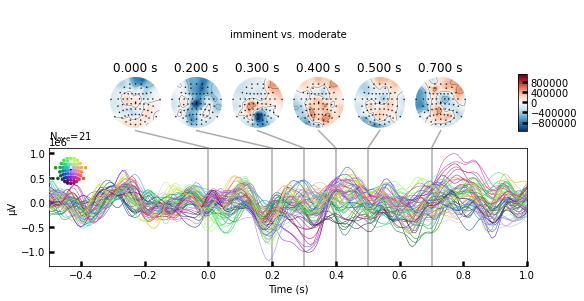

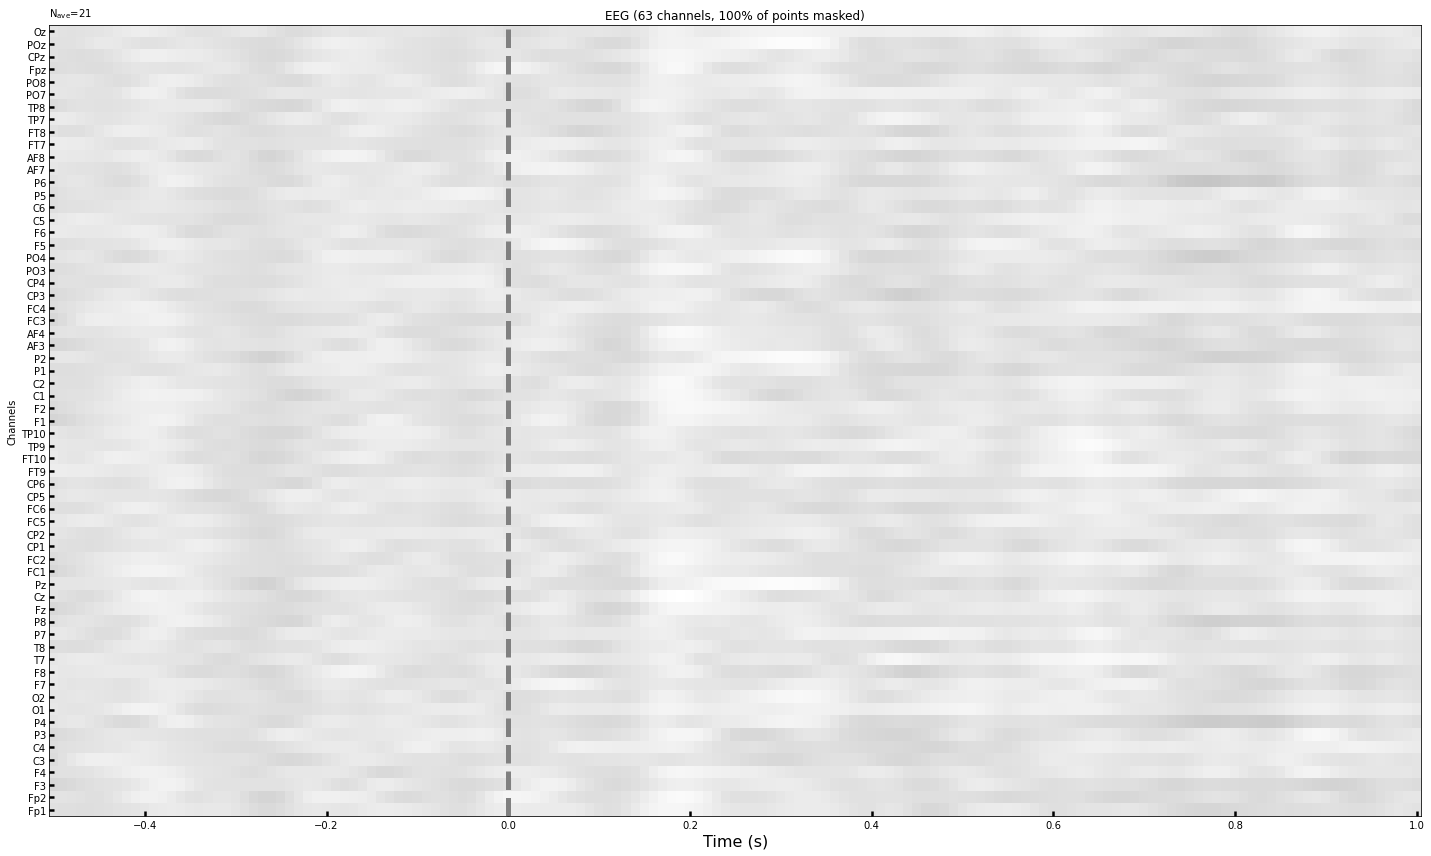

In [99]:
from mne.channels import find_ch_adjacency, make_1020_channel_selections


all_mask = np.zeros((t_obs.shape), dtype=bool)
for i in range(len(cluster_pv)):
    if cluster_pv[i] < 0.05:
        all_mask = all_mask | clusters[i]


# We need an evoked object to plot the image to be masked
evoked = mne.combine_evoked(
    [all_sub_moderate_epoch.average(), all_sub_imminent_epoch.average()], weights=[1, -1]
)  # calculate difference wave
time_unit = dict(time_unit="s")
figsize=(20,12) 
evoked.plot_joint(
    title="imminent vs. moderate", ts_args=time_unit, topomap_args=time_unit, times=[ 0, 0.2, 0.3, 0.4, 0.5, 0.7]
)  # show difference wave

# Create ROIs by checking channel labels
selections = make_1020_channel_selections(evoked.info, midline="12z")

# Visualize the results
# fig, axes = plt.subplots(nrows=3, figsize=(8, 8))
# axes = {sel: ax for sel, ax in zip(selections, axes.ravel())}
# evoked.plot_image(
#     axes=axes,
#     group_by=selections,
#     colorbar=False,
#     show=False,
#     mask=all_mask.T,
#     show_names="all",
#     titles=None,
#     **time_unit,
# )

figsize=(20,12) 
dpi = 100
fig, ax = plt.subplots(figsize=(20, 12))
# Visualize the results
evoked.plot_image(
    axes=ax,
    colorbar=False,
    show=False,
    mask=all_mask.T,
    show_names="all",
    titles=None,
    **time_unit,
)
plt.axvline(0, c="gray", ls = "dashed",linewidth=5)

plt.xlabel('Time (s)', fontsize=16)  # 调整标签字体大小
# plt.colorbar(axes["Left"].images[-1], ax=list(axes.values()), shrink=0.3, label="µV")
plt.tight_layout()
plt.show()

In [61]:
clusters

[(slice(73, 147, None),)]

In [ ]:
import matplotlib.pyplot as plt
plt.close('all')
times = 0.3
timepoint = int(times * 100 + 50)


time_mask = np.squeeze(all_mask.T[:,timepoint])

fig = evoked.plot_topomap(
    mask = all_mask.T, 
    outlines='head',
    times=times, 
    size=6, 
    show_names=False, 
    cmap='RdBu_r',
    vmin=-3500000,
    vmax=3500000,
    scalings=None, 
    sensors='ko',
    # sphere=0.13,
    # extrapolate='head',
    colorbar=False,
    mask_params=dict(marker='o',markersize=5, markerfacecolor='black')
    )# cmap GnBu

In [ ]:
binary_sequence = ""
all_channels = all_sub_imminent_epoch.ch_names
channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
channel_names = []
binary_sequence = [1 if ch in channel_names else 0 for ch in all_channels]
print(binary_sequence)
reshaped_sequence = np.tile(binary_sequence, (151, 1))
print(reshaped_sequence.shape)

evoked = all_sub_imminent_epoch.average()
evoked.plot_topomap(mask = reshaped_sequence.T, mask_params=dict(marker='o',markersize=5, markerfacecolor='black'),
                    times=[ 0.2, 0.3, 0.4, 0.5, 0.7], ch_type='eeg', title='Topographic Map', size=3, 
                    vmin=11000000, vmax=-11000000)
# evoked.plot_topomap(mask = reshaped_sequence.T, mask_params=dict(marker='o',markersize=5, markerfacecolor='black'),
#                     times=[  0.2, 0.3, 0.4, 0.5, 0.7], ch_type='eeg', title='Topographic Map', size=3, )

plt.show()

evoked = all_sub_moderate_epoch.average()
evoked.plot_topomap(mask = reshaped_sequence.T, mask_params=dict(marker='o',markersize=5, markerfacecolor='black'),
                    times=[ 0.2, 0.3, 0.4, 0.5, 0.7], ch_type='eeg', title='Topographic Map', size=3, 
                    vmin=11000000, vmax=-11000000)
evoked.plot_topomap(mask = reshaped_sequence.T, mask_params=dict(marker='o',markersize=5, markerfacecolor='black'),
                    times=[  0.2, 0.3, 0.4, 0.5, 0.7], ch_type='eeg', title='Topographic Map', size=3)

plt.show()

In [ ]:
evoked = mne.combine_evoked(
    [all_sub_moderate_epoch.average(), all_sub_imminent_epoch.average()], weights=[1, -1]
)  # calculate difference wave
time_unit = dict(time_unit="s")
binary_sequence = ""
all_channels = all_sub_imminent_epoch.ch_names
# channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']

binary_sequence = [1 if ch in channel_names else 0 for ch in all_channels]
print(binary_sequence)
reshaped_sequence = np.tile(binary_sequence, (151, 1))
print(reshaped_sequence.shape)

# evoked.plot_joint(
#     title="imminent vs. moderate", ts_args=time_unit, topomap_args=time_unit, times=[ 0, 0.3, 0.4, 0.8], mask=reshaped_sequence.T
# )  # show difference wave
evoked.plot_topomap(mask = reshaped_sequence.T, mask_params=dict(marker='o',markersize=5, markerfacecolor='black'),
                    times=[ 0, 0.2, 0.3, 0.4, 0.5, 0.7,0.8], ch_type='eeg', title='Topographic Map', size=3, )
                    # vmin=3500000, vmax=-3500000)

In [ ]:
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds


# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_imminent_epoch = mne.EpochsArray(data = all_sub_imminent_data, info = info, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
all_sub_moderate_epoch = mne.EpochsArray(data = all_sub_moderate_data, info = info, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.0)) #  -0.5 -0.1
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.0))
all_sub_imminent_epoch.set_montage(mymontage)
all_sub_moderate_epoch.set_montage(mymontage)
adjacency, ch_names = find_ch_adjacency(all_sub_imminent_epoch.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

# mne.viz.plot_ch_adjacency(all_sub_imminent_epoch.info, adjacency, ch_names)


# times = all_smooth_hgb_slow.times

all_sub_moderate_epoch.resample(100)
all_sub_imminent_epoch.resample(100)
# all_sub_imminent_epoch = all_sub_imminent_epoch.crop(-0.5, 1.5)
# all_sub_moderate_epoch = all_sub_moderate_epoch.crop(-0.5, 1.5) # vmpfc(0, 1.1)

all_sub_moderate_epoch.apply_baseline(baseline = (-0.5,-0.1))
all_sub_imminent_epoch.apply_baseline(baseline = (-0.5,-0.1)) 

all_sub_imminent_epoch = all_sub_imminent_epoch.crop(-0.5, 1)
all_sub_moderate_epoch = all_sub_moderate_epoch.crop(-0.5, 1)

In [ ]:
# 假设 'epochs' 是你的 EEG epoch 数据
# 只包括vmpfc
# 整个前额
channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
# channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']
# channel_names = [ 'FC3', 'FC1', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',  'CP3', 'CP1', 'CPz', 'CP2','CP4']

# channel_names = ['Pz', 'P1', 'P3', 'P5', 'P7', 'P2', 'P4', 'P6', 'P8','POz', 'PO3', 'PO7', 'PO4', 'PO8', 'Oz', 'O1', 'O2']

# 选择指定的电极信号
pfc_moderate = all_sub_moderate_epoch.copy().pick_channels(channel_names).average()
pfc_imminent = all_sub_imminent_epoch.copy().pick_channels(channel_names).average()
# 绘制平均信号
# evoked.plot(time_unit='s')
# plt.title("Average of Selected Channels")
# plt.show()
each_sub_mean_data_moderate = np.mean(all_sub_moderate_epoch.pick_channels(channel_names).get_data(), axis=1)
each_sub_mean_data_moderate = np.mean(each_sub_mean_data_moderate[:, 50:150], axis=1)

each_sub_mean_data_imminent = np.mean(all_sub_imminent_epoch.pick_channels(channel_names).get_data(), axis=1)
each_sub_mean_data_imminent = np.mean(each_sub_mean_data_imminent[:, 50:150], axis=1)

0.22129230791094165 0.22678785347815225 (-0.07693466737304043, 0.9390497366060515, True)


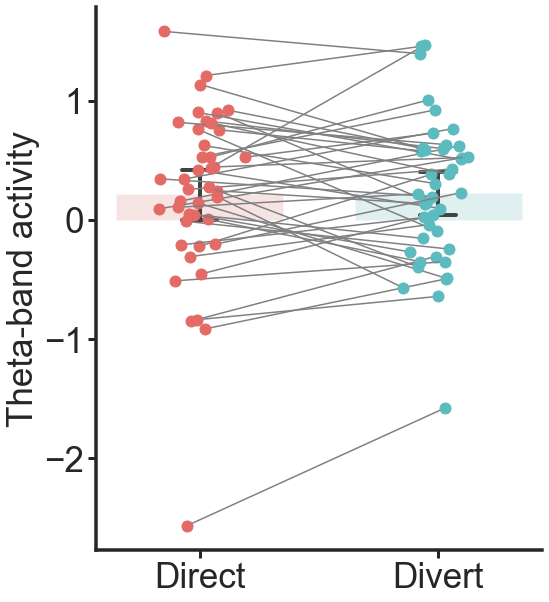

In [119]:
# 画所有被试的正确率 fast正确率，slow正确率，high_p_avg_get_reward

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
point_color = ['#E36A65', '#5CBBBF']
all_data_df = {}

# 正确率
all_data_df["Direct"] = np.array(list(each_sub_mean_data_imminent))
all_data_df["Divert"] = np.array(list(each_sub_mean_data_moderate))
print(np.mean(all_data_df['Direct']), np.mean(all_data_df['Divert']), hm_t_test_rel(all_data_df['Direct'],all_data_df['Divert']))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 3.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    plt.ylabel("Theta-band activity", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


In [ ]:
# paired_ttest
def stat_fun_ttest_ind(X,Y):
    return scipy.stats.ttest_rel(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = all_sub_moderate_epoch.get_data().shape[0] - 1
t_value_threshold = t.ppf(1 - 0.025, degrees_of_freedom)
# print(t_value_threshold)
all_sub_moderate_epoch_copy = all_sub_moderate_epoch.copy()
all_sub_imminent_epoch_copy = all_sub_imminent_epoch.copy()
# all_sub_moderate_epoch_copy.crop(0, 1.2)
# all_sub_imminent_epoch_copy.crop(0, 1.2)

n_permutations = 10000
# 两种情况下相对于0的显著性
T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(np.mean(all_sub_moderate_epoch_copy.get_data(), axis=1), 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(np.mean(all_sub_imminent_epoch_copy.get_data(), axis=1), 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([np.mean(all_sub_moderate_epoch_copy.get_data(), axis=1), np.mean(all_sub_imminent_epoch_copy.get_data(), axis=1)],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=0
                                                                ,threshold=t_value_threshold, stat_fun=stat_fun_ttest_ind)
print('moderate')
print(clusters_fast, cluster_p_values_fast)
print('imminent')
print(clusters_slow, cluster_p_values_slow)
print('compare')
print(clusters, cluster_p_values)

In [ ]:
line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
line_color = ['#5CBBBF', '#E36A65']    # 红色湖蓝色 正确快攻击，正确慢攻击 

# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#E36A65','#FF943C']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#FF943C', '#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6

# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = all_sub_moderate_epoch.times

data_1 = np.mean(all_sub_moderate_epoch.get_data(), axis=1)
data_2 = np.mean(all_sub_imminent_epoch.get_data(), axis=1)
plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))
# plt.plot(times, np.transpose(data_1[-1]))
# plt.legend(subjects)

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[50], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))

se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_fast):
    c = c[0]
    if cluster_p_values_fast[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_slow):
    c = c[0]
    if cluster_p_values_slow[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.04:
        
        plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
#plt.legend((h, ), ('cluster p-value < 0.05', ))
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 17.5])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Theta-band activity", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)